In [1]:
#导入必备的工具
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
trans=transforms.ToTensor()#预处理：变为张量并归一化（灰度值除255）
train_data=datasets.MNIST(root='data',train=True,download=True,transform=trans)
test_data=datasets.MNIST(root='data',train=False,download=True,transform=trans)
train_iter=DataLoader(train_data,batch_size=256,shuffle=True)
test_iter=DataLoader(test_data,batch_size=256,shuffle=False)


In [3]:
#定义网络,先展平（256，28*28），全连接层（输入）-激活函数-全连接层（输出）
net=nn.Sequential(nn.Flatten(),nn.Linear(784,256),nn.ReLU(),nn.Linear(256,10))

In [4]:
loss=nn.CrossEntropyLoss()#交叉熵损失
trainer=torch.optim.SGD(net.parameters(),lr=0.1)

In [5]:
num_epochs=20#训练10轮
train_loss_history=[]#记录loss
test_acc_history=[]#记录accuracy

for epoch in range(num_epochs):
    net.train()#训练模式
    total_loss,num_batches=0.0,0
    for X,y in train_iter:
        y_hat=net(X)#前向传播
        l=loss(y_hat,y)
        trainer.zero_grad()#清梯度
        l.backward()#反向传播
        trainer.step()
        total_loss+=l.item()#张量变标量累加
        num_batches+=1
    avg_loss=total_loss/num_batches
    train_loss_history.append(avg_loss)#画图用

    net.eval()#测试模式
    correct,total=0,0
    with torch.no_grad():#测试时不记录梯度 省内存
        for X,y in test_iter:
            y_hat=net(X)
            correct+=(y_hat.argmax(dim=1)==y).sum().item()#数一数做对了几道
            total+=y.shape[0]
    acc=correct/total
    test_acc_history.append(acc)
    print(f'epoch{epoch+1}:loss={avg_loss:.4f},test_acc={acc:.4f}')

epoch1:loss=0.7637,test_acc=0.8975
epoch2:loss=0.3472,test_acc=0.9147
epoch3:loss=0.2953,test_acc=0.9260
epoch4:loss=0.2624,test_acc=0.9305
epoch5:loss=0.2370,test_acc=0.9374
epoch6:loss=0.2163,test_acc=0.9421
epoch7:loss=0.1989,test_acc=0.9456
epoch8:loss=0.1842,test_acc=0.9504
epoch9:loss=0.1718,test_acc=0.9516
epoch10:loss=0.1603,test_acc=0.9545
epoch11:loss=0.1506,test_acc=0.9554
epoch12:loss=0.1414,test_acc=0.9604
epoch13:loss=0.1334,test_acc=0.9597
epoch14:loss=0.1260,test_acc=0.9629
epoch15:loss=0.1199,test_acc=0.9638
epoch16:loss=0.1139,test_acc=0.9657
epoch17:loss=0.1087,test_acc=0.9650
epoch18:loss=0.1038,test_acc=0.9676
epoch19:loss=0.0994,test_acc=0.9680
epoch20:loss=0.0951,test_acc=0.9692


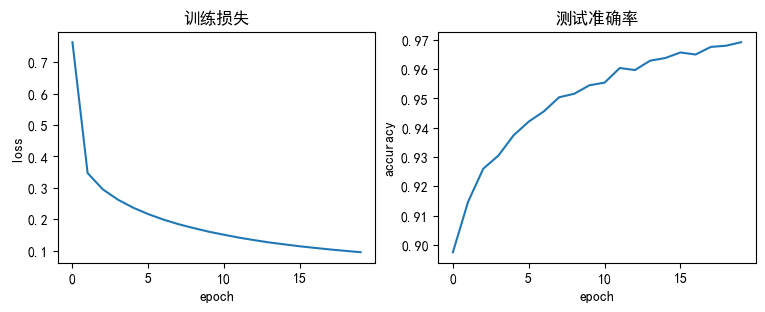

In [6]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('训练损失')
plt.subplot(1, 2, 2)
plt.plot(test_acc_history)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('测试准确率')
plt.show()

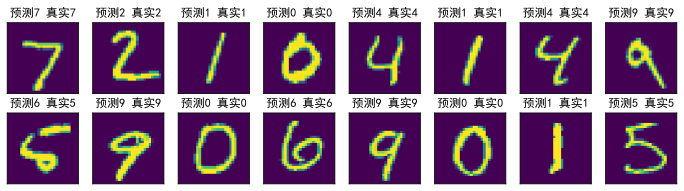

In [7]:
X,y=next(iter(test_iter))
with torch.no_grad():
    y_hat=net(X)
preds=y_hat.argmax(dim=1)
from d2l import torch as d2l 
d2l.set_figsize((7,3.5))
d2l.show_images(X[:16].reshape(16, 28, 28), 2, 8,
                titles=[f'预测{p} 真实{t}' for p, t in zip(preds[:16], y[:16])])
plt.show()

In [8]:
print(torch.cuda.is_available())

True
